# Time-domain: a Radiating Dipole

The previous notebooks solved static and quasi-static problems, where the field
everywhere is determined at once by a single matrix solve. Here nothing is solved:
the full Maxwell equations are stepped forward in time, and the field propagates.

The two curl equations are integrated in a leapfrog scheme, each advancing one
field using the other:

$$\mathbf{M}_\varepsilon \frac{d\hat{e}}{dt} = \tilde{\mathbf{C}}\hat{h} - \hat{\hat{\jmath}},
\qquad
\frac{d\hat{\hat{b}}}{dt} = -\mathbf{C}\hat{e}$$

The two fields are staggered in time as well as in space: $\hat{e}$ lives at half
steps and $\hat{h}$ at whole steps, so each update uses the other field at exactly
the midpoint of its own interval. That is what makes the scheme second-order
accurate despite each individual step being a simple difference.

**No matrix is ever inverted.** Both material matrices are diagonal, so the update
is elementwise multiplication and two sparse matrix–vector products. That is the
appeal of the explicit method: each step is cheap, and memory is proportional to
the number of unknowns rather than to the fill-in of a factorisation.

**The price is a step-size limit.** Information travels at most one cell per step
on the grid, so the time step must satisfy the Courant condition

$$\Delta t \leq \frac{1}{c\sqrt{\Delta x^{-2} + \Delta y^{-2} + \Delta z^{-2}}} .$$

Exceed it and the scheme does not merely lose accuracy — it diverges exponentially.
`get_vacuum_cfl_time` returns this limit; the runs below use $99\%$ of it.

The boundary here is a perfect electric conductor, imposed by zeroing the
tangential electric field. That makes the domain a closed metal box, so the
radiated wave reflects off the walls and returns. It is the simplest boundary to
implement and the wrong one for a radiation problem — which is exactly why it is
worth seeing before adding an absorbing layer.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io = devnull)
Pkg.develop(path = joinpath(@__DIR__, "..", ".."); io = devnull)
using FITToolbox;
using Statistics
using LinearAlgebra
using CairoMakie
CairoMakie.activate!(type = "png", px_per_unit = 1)
using IterativeSolvers
using SparseArrays

function get_tangential_boundary(config::FITDomain)
    diag_vec = ones(Float64, 3*config.Np)
    # zero out the tangential entries; the rest pass through unchanged
    diag_vec[get_all_tangential_boundary_indices(config)] .= 0.0
    return spdiagm(0 => diag_vec)
end

get_tangential_boundary (generic function with 1 method)

## Domain and source placement

A $200 \times 200 \times 200\;\text{mm}$ vacuum domain at $2\;\text{mm}$
resolution. At the $10\;\text{GHz}$ used below the wavelength is $30\;\text{mm}$,
so the grid resolves it with fifteen cells — comfortably above the ten or so
usually taken as the minimum for acceptable numerical dispersion.

Placing the source takes two steps because the requested position and the
available position are not the same thing. Current is a facet-integrated
quantity, so the excitation must sit on a **dual facet**, and dual facets exist
only at discrete places on the grid. The coordinates computed from
`MyDomain.nodes_*` give the geometric centre of the domain; whether a dual facet
happens to lie exactly there depends on the parity of the cell count.

`get_index_entity` resolves this: it finds the nearest dual facet with a
$z$-normal, returns its index in the state vector, and warns if the snap moved
further than `atol`. The `DirZ()` argument is required because a facet is
directional — there are three at every grid location, and the dipole's moment
points along $z$.

`get_position_of_index` then reads the position back. That value, not the
requested one, is where the source actually is, and it is what the plots later
mark. Using the requested coordinates instead would put the marker up to half a
cell away from the real source — invisible at this resolution, but the sort of
discrepancy that becomes confusing on a coarser grid.

Note that `MyDomain.nodes_*` store metres regardless of the `units` argument used
to build the domain, hence the factor of $1000$. The `units` keyword converts
inputs; it never changes what the struct holds.

In [2]:
MyDomain = create_domain([200,200,200],[2,2,2];units="mm",σ=0,ε_r=1,μ_r=1); 

# These are the approximate coordinates where dipole should be placed
# However, the imprinted current lives on the dual facet and the correct
# position is found via function get_index_entity
x_dipole = MyDomain.nodes_u[end] / 2.0 * 1000 #convert to mm
y_dipole = MyDomain.nodes_v[end] / 2.0 * 1000 #convert to mm
z_dipole = MyDomain.nodes_w[end] / 2.0 * 1000 #convert to mm

index_dipole = get_index_entity(MyDomain, DualFacet(), DirZ(), x_dipole, y_dipole, z_dipole; units="mm", atol=0.005);

# For plotting, the dipole positions are updated
x_dipole, y_dipole, z_dipole = get_position_of_index(MyDomain, DualFacet(), index_dipole; units="mm");


## Operators and material matrices

Everything the time loop needs is built once here.

The three material matrices are diagonal, each holding a ratio of dual to primal
geometry scaled by the local material: $\mathbf{M}_\varepsilon$ maps edge voltages
to fluxes through dual facets, $\mathbf{M}_\nu$ maps facet fluxes to magnetic
voltages along dual edges, and $\mathbf{M}_\sigma$ would carry conductive loss.
Here the domain is vacuum throughout, so $\mathbf{M}_\sigma$ is identically zero
and the loop below ignores it — it is built only so the same code can be reused
when a lossy material is added.

The two curls carry no material information at all. $\mathbf{C}$ maps primal edges
to primal facets, $\tilde{\mathbf{C}}$ maps dual edges to dual facets, and both
contain nothing but $\pm 1$. They are exact: the discrete identities
$\mathbf{S}\mathbf{C} = 0$ and $\mathbf{C}\mathbf{G} = 0$ hold to machine
precision on any grid, uniform or not, which is why charge conservation in the
scheme follows from the operators themselves rather than from careful
discretisation.

The two curl operators are related by $\tilde{\mathbf{C}} = \mathbf{C}^\mathsf{T}$, so building
both is a convenience rather than a necessity. All the approximation in the method
sits in the material matrices; the topology is error-free.

In [3]:
M_ν = get_reluctivity(MyDomain);
M_σ = get_conductivity(MyDomain)
M_ε = get_permittivity(MyDomain)

C = get_curl(MyDomain,Primal());
C̃ = get_curl(MyDomain, Dual());

## Excitation and time step

The source is a sinusoidal current at $10\;\text{GHz}$, driven through the single
dual facet located above. At that frequency the free-space wavelength is
$\lambda = 30\;\text{mm}$, resolved by fifteen cells on this grid.

The time step comes from the Courant limit, which on a uniform $2\;\text{mm}$ grid
is

$$\Delta t \leq \frac{\Delta}{c\sqrt{3}} \approx 3.85\;\text{ps},$$

and the run uses $99\%$ of it. That leaves about $26$ steps per period, which is
ample: the accuracy of an explicit scheme is limited by the spatial resolution
long before the temporal one, and running below the limit buys nothing except
more steps. Exceeding it, on the other hand, makes the scheme diverge
exponentially rather than merely inaccurate — hence the safety factor rather than
the exact limit.

One caveat about this particular source. A sine switched on at $t=0$ is
discontinuous in its derivative, so its spectrum is not confined to $10\;\text{GHz}$:
the switch-on transient carries broadband content extending well past what the grid
can resolve. Those components propagate at the wrong speed and appear in the plots
as a faint precursor ahead of the physical wavefront. A smoothly ramped or
Gaussian-modulated source would avoid it, at the cost of a less direct comparison
with the steady-state field.

In [4]:
#FDTD excitation
f = 10e9           # Operating frequency in Hz
ω = 2π * f         # Angular frequency
A_p = 1            # Peak amplitude

I_src(t) = A_p * sin(ω * t)

Δt = get_vacuum_cfl_time(MyDomain) * 0.99;

## The time loop

Discretising the two curl equations in time with central differences about the
staggered points gives the update pair directly. Faraday's law, differenced about
step $n$:

$$\hat{\hat{b}}^{\,n+1} = \hat{\hat{b}}^{\,n} - \Delta t\, \mathbf{C}\, \hat{e}^{\,n+1/2}$$

and Ampère's law, differenced about step $n+1$:

$$\hat{e}^{\,n+3/2} = \hat{e}^{\,n+1/2}
  + \Delta t\, \mathbf{M}_\varepsilon^{-1}\left(\tilde{\mathbf{C}}\, \hat{h}^{\,n+1} - \hat{\hat{\jmath}}^{\,n+1}\right)$$

with the constitutive relation $\hat{h} = \mathbf{M}_\nu \hat{\hat{b}}$ closing the
loop. In the code the flux and the magnetic voltage are folded into one variable,
so the first line is written as

$$\hat{h}^{\,n+1} = \hat{h}^{\,n} - \Delta t\, \mathbf{M}_\nu\, \mathbf{C}\, \hat{e}^{\,n+1/2}.$$

Each field is evaluated at the midpoint of the other's interval — $\hat{e}$ at half
steps, $\hat{h}$ at whole ones — which is what makes a scheme built from plain
differences second-order accurate. It also means the two are never known at the
same instant, so any quantity combining them, such as the Poynting flux, needs
interpolating in time.

Three points about how the loop is written rather than what it computes.

**Everything is an argument.** At notebook top level each reference to a variable
is a dynamically dispatched global lookup. On arrays of millions of elements that
turns a loop which should run in seconds into one that takes minutes. Passing the
operators and material data in lets the compiler specialise on their concrete
types.

**No matrices appear inside the loop.** The material matrices are diagonal, so
they are extracted once into plain vectors and the constitutive relations become
elementwise multiplication. Combined with `mul!` writing into preallocated
buffers, the loop allocates nothing at all after the setup — which matters when it
runs for thousands of steps.

**A guard against division by zero.** The reciprocal of $\mathbf{M}_\varepsilon$ is
taken elementwise, so a zero entry would produce `Inf` and, one multiplication by
zero later, turn the whole field into `NaN`. In this domain that cannot happen —
the ghost layer used when averaging the material gives every edge a finite dual
facet area, including those in the last plane. The guard costs one pass over the
array and makes the function safe for material distributions where it would
matter.

The source enters as a single subtraction at the one dual facet located earlier.
Because it is one entry rather than a vector, there is no need to build and zero a
full-length current array each step.

The PEC wall is applied by multiplying through by `pec`, which is zero on the
tangential boundary edges and one elsewhere. Fusing it into the same broadcast as
the update avoids a second pass over the array.

Only the steps listed in `targets` are stored. Keeping every step would cost
`nsteps × n_dof × 8` bytes per field — tens of gigabytes on this grid — for data
of which only nine frames are ever plotted.

In [5]:
"""
    run_fdtd_lossless(C, C̃, M_ε, M_ν, pec, index_dipole, I_src, Δt, nsteps, targets)

Leapfrog time stepping without material loss. ê lives at half steps, ĥ at whole
steps. Only the snapshots in `targets` are kept — storing every step would cost
nsteps × n_dof × 8 bytes, far too much on a large grid.

Everything is passed in as an argument rather than read from global scope: at
notebook top level each reference is a dynamic dispatch, which on arrays of
millions of elements costs minutes instead of milliseconds.
"""
function run_fdtd_lossless(C, C̃, M_ε, M_ν, pec, index_dipole, I_src, Δt, nsteps, targets)
    # Diagonal material matrices reduce to plain vectors, so the whole update is
    # broadcast arithmetic with no matrix objects in the loop.
    Δt_ν = Δt .* diag(M_ν)
    dε   = diag(M_ε)
    dε[dε .== 0] .= Inf              # dead edges: reciprocal 0 rather than Inf
    Δt_ε⁻¹ = Δt ./ dε

    n_dof = size(M_ν, 1)
    ê   = zeros(n_dof)               # edge voltages
    ĥ   = zeros(n_dof)               # magnetic voltages along dual edges
    src = zeros(n_dof)               # C̃ĥ - ĵ̂, right-hand side of the e-update
    tmp = zeros(n_dof)

    ê_history, ê_times = Vector{Vector{Float64}}(), Float64[]
    sizehint!(ê_history, length(targets))

    t = Δt / 2
    for step in 1:nsteps
        if step in targets
            push!(ê_history, copy(ê)); push!(ê_times, t)
        end

        # Faraday:  ĥ ← ĥ - Δt M_ν (C ê)
        mul!(tmp, C, ê)
        @. ĥ -= Δt_ν * tmp

        # Ampère with the source, then the PEC wall:
        #   ê ← pec ⊙ (ê + Δt M_ε⁻¹ (C̃ ĥ - ĵ̂))
        mul!(src, C̃, ĥ)
        src[index_dipole] -= I_src(t)
        @. ê = pec * (ê + Δt_ε⁻¹ * src)

        t += Δt
    end

    return ê_history, ê_times
end

run_fdtd_lossless

## Running

The parameters are fixed here rather than inside the function, so the same loop
can be re-run with a different duration or a different boundary without rebuilding
anything.

The run covers $500\;\text{ps}$, which at $\Delta t \approx 3.81\;\text{ps}$ is
$131$ steps. Light travels $150\;\text{mm}$ in that time, against a half-width of
$100\;\text{mm}$ from the source to the nearest wall — so the wave reaches the
boundary at about $334\;\text{ps}$ and the last third of the run shows the
reflection coming back. That is deliberate: with a PEC wall the reflection is the
point.

`targets` picks nine steps spread over the run, skipping the first tenth where the
field is still building. A `Set` rather than a vector because the membership test
runs every step and duplicates from rounding would otherwise store the same frame
twice.

`pec` is the diagonal of the tangential-boundary projection, extracted as a plain
vector so the loop can apply it by broadcasting rather than by a matrix product.

The `@time` reports allocations as well as duration. After the setup the loop
should allocate nothing per step; a large allocation count would mean something
inside is still creating temporaries, which on a run of this size is worth
chasing.

In [6]:
nsteps  = ceil(Int, (5e-10 - Δt/2) / Δt)
targets = Set(round.(Int, LinRange(max(1, nsteps ÷ 10), nsteps, 9)))
pec     = diag(get_tangential_boundary(MyDomain))

@time ê_history, ê_times =
    run_fdtd_lossless(C, C̃, M_ε, M_ν, pec, index_dipole, I_src, Δt, nsteps, targets);

 87.203427 seconds (2.82 M allocations: 887.219 MiB, 1.10% gc time, 2.28% compilation time)


## Snapshots

Nine frames through the run, on a plane containing the dipole. Two versions of the
same data are produced, because the choice of what to plot changes what is visible.

**The signed $E_z$ component**, shown first, is the more informative. The dipole
points along $z$, so $E_z$ carries the sign alternation of the wave: successive
wavefronts appear as alternating red and blue rings on a diverging colormap, and
the outward propagation is immediate to read. A magnitude cannot show this — it is
positive everywhere and the alternation collapses into a series of nodal lines.

The colour range is set by the 99th percentile of the field rather than its
maximum. Near the source the field is orders of magnitude larger than in the
radiation zone, and scaling to the peak would flatten everything outside the first
few cells into a single shade.

**The magnitude**, on a logarithmic scale, is useful for judging decay rather than
structure. Its range is clipped to four decades below the peak. That is not
cosmetic: below about $10^{-6}$ of the peak the plot shows the numerical precursor
rather than the field. Each time step couples only nearest neighbours, so after
$n$ steps nothing can have travelled further than $n$ cells along any axis — the
reachable region is an $L^1$ ball, a diamond, expanding faster than the physical
wave. What lies inside that diamond but outside the wavefront is at the level of
the switch-on transient and numerical dispersion, not physics. Raising the floor
clips it away.

Both figures use one colour range across all nine panels, so a brighter frame means
a stronger field rather than a rescaled axis. Axis labels appear only on the outer
row and column.

The last panels are worth comparing against the run length: the wave reaches the
nearest wall at about $334\;\text{ps}$, so the final frames show it reflected. With
a PEC boundary nothing leaves the domain, and what returns superposes on the
outgoing field — visible as the ring pattern losing its clean radial symmetry near
the edges.

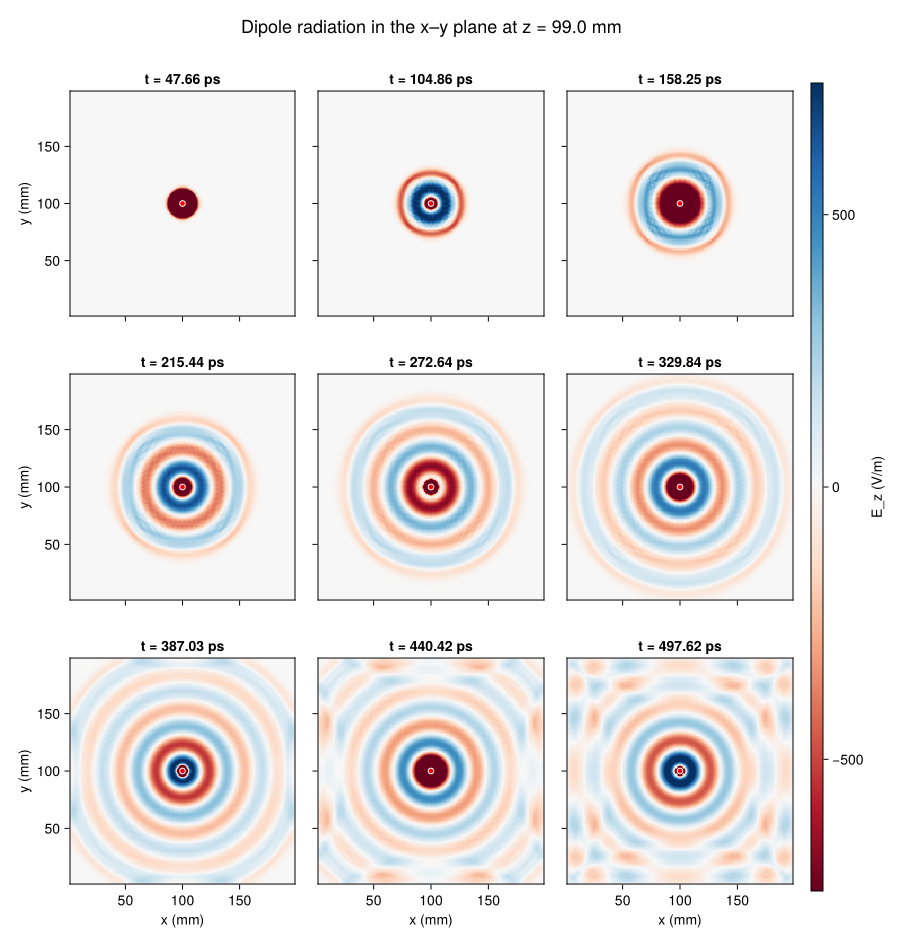

In [7]:
# Sampling grid in mm, one node in from each boundary so the interpolation always
# has a full stencil. MyDomain stores metres, hence the scaling.
mm = 1e-3
xs = LinRange(MyDomain.nodes_u[2]/mm, MyDomain.nodes_u[end-1]/mm, 200)
ys = LinRange(MyDomain.nodes_v[2]/mm, MyDomain.nodes_v[end-1]/mm, 200)

# Interpolate ê onto the cut plane at z_dipole and reduce each triple of field
# components with f — b -> hypot(b...) for the magnitude, last for E_z.
sample_slice(ê, f) =
    [f(FITToolbox.interpolate(MyDomain, PrimalEdge(), ê, x, y, z_dipole; units="mm"))
     for x in xs, y in ys]

# Nine snapshots in a 3×3 grid sharing one colour range, so a brighter panel means
# a stronger field rather than a rescaled axis. Axis labels only on the outer row
# and column, to keep the grid readable.
function snapshot_grid(slices, times, colorrange, colormap, label)
    fig = Figure(size = (900, 950))
    Label(fig[0, 1:3],
          "Dipole radiation in the x–y plane at z = $(round(z_dipole, digits=1)) mm";
          fontsize = 18, padding = (0, 0, 8, 0))

    for (n, slice) in enumerate(slices)
        row, col = fldmod1(n, 3)
        ax = Axis(fig[row, col];
                  title  = "t = $(round(times[n] * 1e12, digits=2)) ps",
                  aspect = DataAspect(),
                  xlabel = row == 3 ? "x (mm)" : "",
                  ylabel = col == 1 ? "y (mm)" : "",
                  xticklabelsvisible = row == 3,
                  yticklabelsvisible = col == 1)

        heatmap!(ax, xs, ys, slice; colormap, colorrange)
        scatter!(ax, [x_dipole], [y_dipole];
                 color = :red, markersize = 8, strokewidth = 1, strokecolor = :white)
    end

    Colorbar(fig[1:3, 4]; colorrange, colormap, label)
    return fig
end


# --- magnitude, logarithmic ---------------------------------------------------
# The floor prevents log10(0) where the field passes through zero.
mag = [log10.(max.(sample_slice(ê, b -> hypot(b...)), 1e-15)) for ê in ê_history]
vmax = maximum(maximum, mag)
fig_mag = snapshot_grid(mag, ê_times, (vmax - 4, vmax), :viridis, "log₁₀(|E|) (V/m)")

# --- z-component, signed ------------------------------------------------------
# The dipole points along z, so E_z carries the sign alternation of the wave. A
# diverging colormap on a symmetric range makes the wavefronts far more legible
# than a magnitude, which is positive everywhere. The 99th percentile rather than
# the maximum keeps the near-field spike from flattening everything else.
ez   = [sample_slice(ê, last) for ê in ê_history]
vabs = quantile(abs.(vcat(vec.(ez)...)), 0.99)
fig_ez = snapshot_grid(ez, ê_times, (-vabs, vabs), :RdBu, "E_z (V/m)")

fig_ez

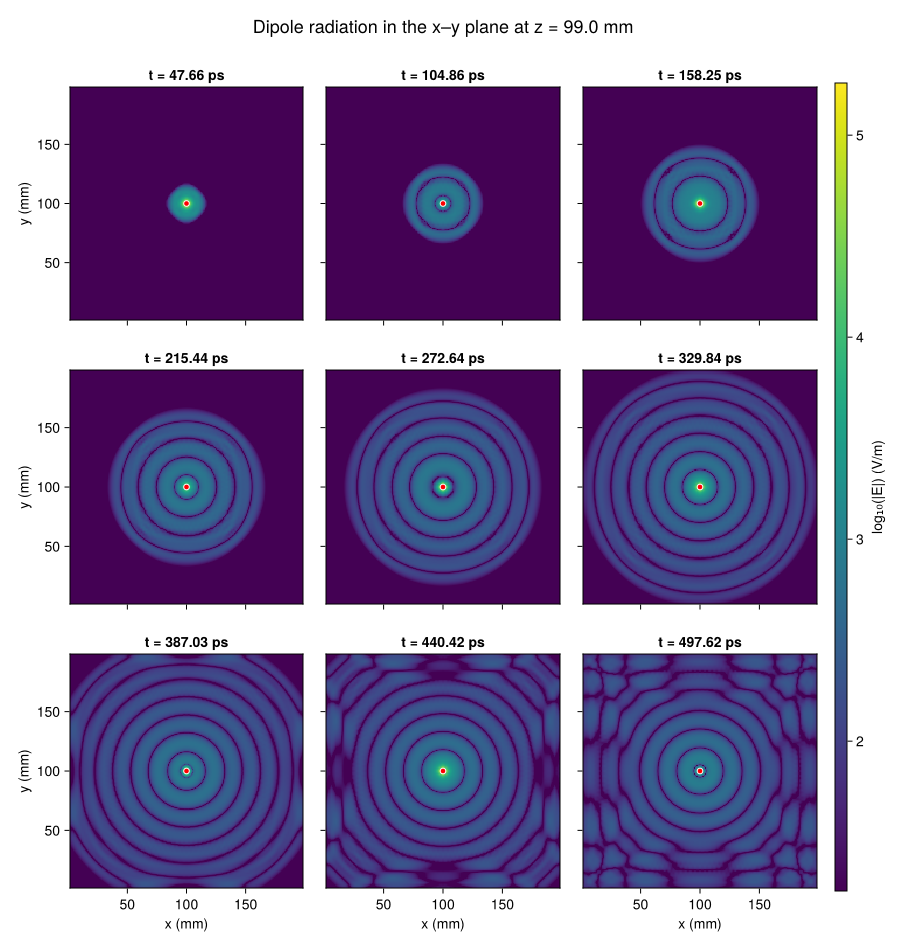

In [8]:
fig_mag